<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #2: Linear Classifiers and Multilayer Perceptrons</h2>
Semester 1, 2026<br>
</center>


**Due**: 11:59pm on Sunday 8 March, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`).

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [1]:
# TODO: Replace with your name and university ID
student_name = "Kyar-Hsing Ma"
student_id = "u7976564"

## Disclosure

TODO: doucment any use of online resources (other than course material) and/or generative AI tools.

In [2]:
# The ANU lab machines will have python and the necessary packages already installed. If you're working
# on your own machine you will need to install python with Jupyter notebook, OpenCV and PyTorch:
#  - Documentation for the OpenCV computer vision library is here: https://opencv.org/. You should be able
#    to install the library on your computer using `pip install opencv-python` or if you have conda
#    `conda install conda-forge::opencv`.
#  - Documentation for the PyTorch deep learning library is here: https://pytorch.org/. Follow the
#    installation instructions (for the stable release, v2.9.1 at time of writing), being sure to install
#    both `pytorch` and `torchvision`. You will not need access to a GPU for this course but having one
#    may increase computation speed.
#  Browse through the user documentation and tutorials for these libraries.

import sys
import getpass

def is_notebook():
    return 'ipykernel' in sys.modules

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
if is_notebook():
    print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
    print("Python Version: {}".format(sys.version))
    print("PyTorch Version: {}".format(torch.__version__))

User: aunghein (Kyar-Hsing Ma, u7976564)
Python Version: 3.11.14 | packaged by conda-forge | (main, Jan 27 2026, 00:01:01) [Clang 19.1.7 ]
PyTorch Version: 2.10.0


In [3]:
device = torch.device("cpu")
random_seed = 32426242
torch.manual_seed(random_seed)

In [4]:
# Preliminaries -- Generating an synthetic binary classification dataset that follows the XOR function 
# Conceptually, the 2D feature vectors can be seen as randomly generated points on a 2d plane
# and the corresponding labels denotes where the coordinates of the points have the same sign. 
def gen_xor_data(
    num_samples: int, train_ratio: float = 0.9
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Generate XOR data.

    Args:
        num_samples (int): number of samples to generate.

    Returns:
        tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]: tuple of (x_train, y_train, x_test, y_test) where x is the input data and y is the label.
    """
    x = torch.rand(num_samples, 2)
    y = torch.zeros(num_samples, dtype=torch.long)
    for i in range(num_samples):
        if x[i, 0] > 0.5:
            if x[i, 1] > 0.5:
                y[i] = 0
            else:
                y[i] = 1
        else:
            if x[i, 1] > 0.5:
                y[i] = 1
            else:
                y[i] = 0
    x -= 0.5
    num_train_data = int(len(x) * train_ratio)
    return x[:num_train_data], y[:num_train_data], x[num_train_data:], y[num_train_data:]


x_train, y_train, x_test, y_test = gen_xor_data(1000)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

(torch.Size([900, 2]),
 torch.Size([900]),
 torch.Size([100, 2]),
 torch.Size([100]))

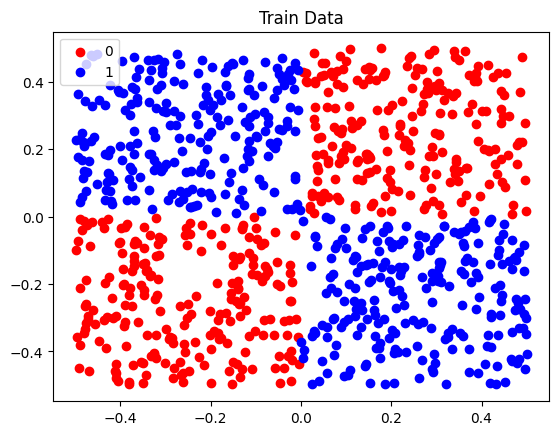

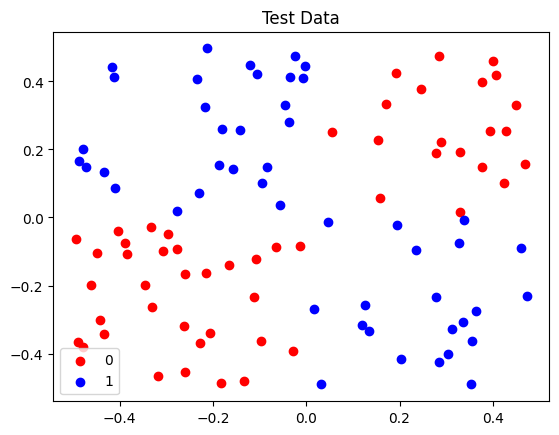

In [5]:
if is_notebook():# Visualise XOR data
    def visualize_xor_data(x: torch.Tensor, y: torch.Tensor, title: str = None):
        plt.scatter(x[y == 0, 0], x[y == 0, 1], color="red", label="0")
        plt.scatter(x[y == 1, 0], x[y == 1, 1], color="blue", label="1")
        plt.legend()
        if title:
            plt.title(title)
        plt.show()


    visualize_xor_data(x_train, y_train, "Train Data")
    visualize_xor_data(x_test, y_test, "Test Data")

## Task 1 -- Linear Forward 

In [6]:
# --- TASK 1 -----
# Implement an linear forward function 
# Given input x, weight matrix A and bias vector b, return the output y
def linear_forward(x: torch.Tensor, A: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """One forward pass of a single-layer perceptron (one linear layer).

    Args:
        x (torch.Tensor): The input to the linear layer, of shape (B, D).
        A (torch.Tensor): The weight matrix of the linear layer, of shape (H, D).
        b (torch.Tensor): The bias vector of the linear layer, of shape (H,).

    Returns:
        torch.Tensor: The output of the linear layer, needs to be in the shape of (B, H).

    Notes:
        Checkout PyTorch's implementation of `torch.nn.Linear`: https://pytorch.org/docs/stable/generated/torch.nn.Linear.html.
    """
    # TODO: implement the forward pass of a single-layer perceptron.
    return torch.matmul(x, A.T) + b
    # B,D= x.shape
    # H,_ = A.shape
    # return torch.matmul(A.view(1,H,D),x.view(B,D,1)).view(B,H) + b.view(1,H)



In [7]:
# Tests for task 1
if is_notebook():
    # creating a linear layer with randomly initialised weight and bias
    in_features = 2
    out_features = 2
    linear_model = nn.Linear(in_features, out_features)
    # print out the weight and bias
    weight = linear_model.weight
    bias = linear_model.bias
    print(f'weight: {weight}')
    print(f'bias: {bias}')
    # verify that the output of the function has the correct shape
    output = linear_forward(x_test, weight, bias)
    print(f'shape of output: {output.shape}')
    # verify that linear_forward is functionally correct
    assert torch.allclose(linear_model(x_test), output), 'Your linear forward function does not match PyTorch\'s implementation\n'

weight: Parameter containing:
tensor([[-0.5063,  0.0961],
        [-0.6249,  0.5898]], requires_grad=True)
bias: Parameter containing:
tensor([0.4931, 0.5167], requires_grad=True)
shape of output: torch.Size([100, 2])


## Task 2 -- Calculate Accuracy 


In [8]:
# --- TASK 2 --------------------------------------------------------------------------------------
# Implement a basic classification metric -- accuracy   
def calculate_accuracy(output: torch.Tensor, target: torch.Tensor) -> float:
    """Calculates the accuracy given `output` and `target`.

    The accuracy is the number of correct predictions divided by the total number of predictions.

    Args:
        output (torch.Tensor): The unnormalized output from the model, of shape (B, C).
        target (torch.Tensor): The ground truth labels, of shape (B,).

    Returns:
        float: The accuracy.

    Notes:
        The result should be converted to a `float`.
    """
    # TODO: implement the accuracy calculation.
    predictions = output.argmax(dim=1)
    return (predictions == target).float().mean().item()


Epoch: 10/100 Loss: 0.6937
Epoch: 20/100 Loss: 0.6927
Epoch: 30/100 Loss: 0.6926
Epoch: 40/100 Loss: 0.6922
Epoch: 50/100 Loss: 0.6920
Epoch: 60/100 Loss: 0.6921
Epoch: 70/100 Loss: 0.6920
Epoch: 80/100 Loss: 0.6920
Epoch: 90/100 Loss: 0.6920
Epoch: 100/100 Loss: 0.6920


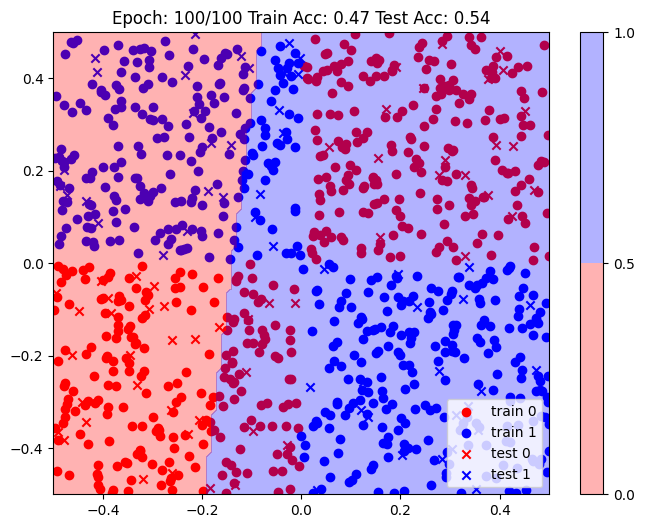

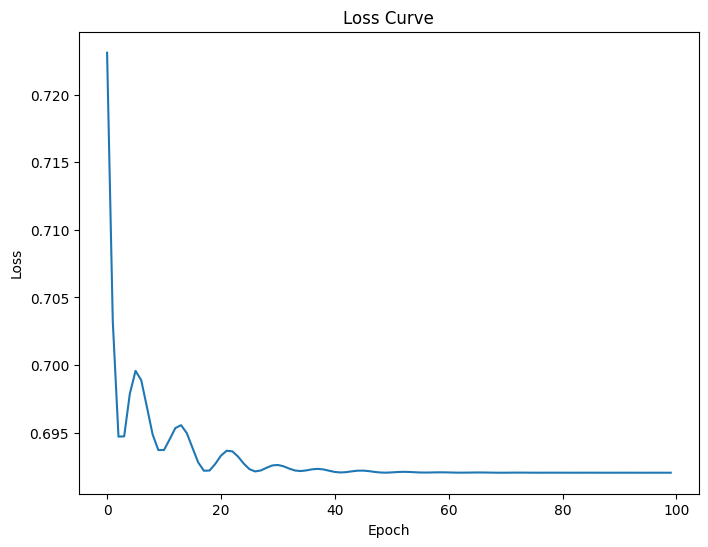

In [9]:
# Tests for Task 2.

if is_notebook():
    from lab02_utils import  train_model
    # Recall the linear model created for testing task 1     
    in_features = 2
    out_features = 2
    linear_model = nn.Linear(in_features, out_features)
    weight = linear_model.weight
    bias = linear_model.bias
    linear_model.forward = lambda x: linear_forward(x, weight, bias)    
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=linear_model,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=nn.CrossEntropyLoss(),
        accuracy_fn=calculate_accuracy,
        num_epochs=100,
        print_every_epochs=10,
        evaluate_every_epochs=100,
        lr=0.1,
        temperature=None,
    )

    

## Task 3 -- 2-layer MLP

In [10]:
# --- TASK 3 --------------------------------------------------------------------------------------
# Build a basic neural network 

def build_two_layer_mlp(in_features: int = 2, out_features: int = 2, hidden_features: int = 4) -> nn.Module:
    """Builds a two-layer multi-layer perceptron (MLP) with ReLU activation functions in between.

    Args:
        in_features (int, optional): Number of input features. Defaults to 2.
        out_features (int, optional): Number of output features. Defaults to 2.
        hidden_features (int, optional): Number of hidden features. Defaults to 4.

    Returns:
        nn.Module: A PyTorch module representing the MLP.

    Notes:
        Use the `torch.nn` module to create `Linear` (with bias) and `ReLU` layers. We then wrap all layers using `Sequential`.
        Documentation for `Linear`: https://pytorch.org/docs/stable/generated/torch.nn.Linear.html.
        Documentation for `ReLU`: https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html.
        Documentation for `Sequential`: https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html.
    """
    # TODO: implement the two-layer MLP by creating two linear layers of appropriate size and a non-linear activation layer,
    # replacing `None` with the relevant PyTorch functions. See comments above for details.
    linearLayer1 = nn.Linear(in_features, hidden_features, bias=True)
    activationLayer = nn.ReLU()
    linearLayer2 = nn.Linear(hidden_features, out_features, bias=True)
    
    return nn.Sequential(linearLayer1, activationLayer, linearLayer2)



Epoch: 10/100 Loss: 0.6210
Epoch: 20/100 Loss: 0.4239
Epoch: 30/100 Loss: 0.2658
Epoch: 40/100 Loss: 0.1747
Epoch: 50/100 Loss: 0.1322
Epoch: 60/100 Loss: 0.1086
Epoch: 70/100 Loss: 0.0937
Epoch: 80/100 Loss: 0.0837
Epoch: 90/100 Loss: 0.0763
Epoch: 100/100 Loss: 0.0704


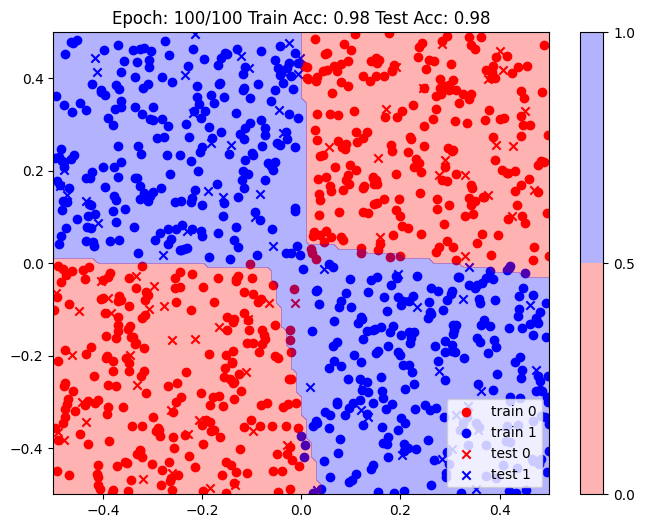

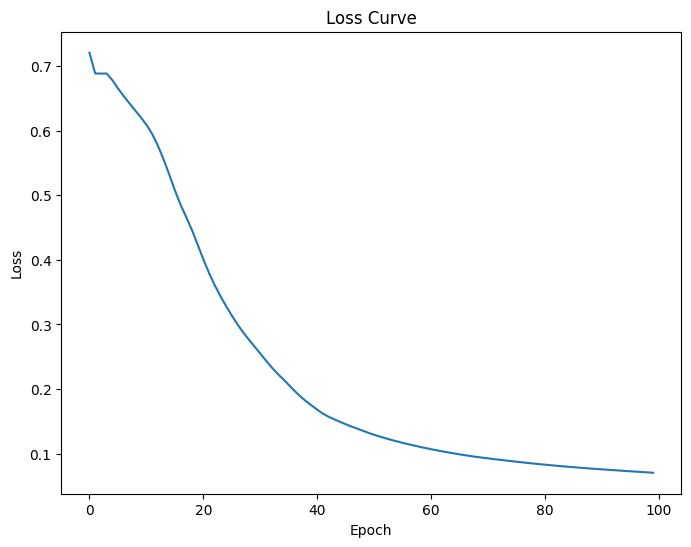

In [11]:
# Tests for Task 3.

if is_notebook():
    # testing out the 2-layer mlp
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=build_two_layer_mlp(2, 2, 4),
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=nn.CrossEntropyLoss(),
        accuracy_fn=calculate_accuracy,
        num_epochs=100,
        print_every_epochs=10,
        evaluate_every_epochs=100,
        lr=0.1,
        temperature=None,
    )


## Task 4 -- Temperature-scaled Cross-entropy Loss

In [12]:
# --- TASK 4 --------------------------------------------------------------------------------------
# Define the loss function for the classification task 

def cross_entropy_loss(output: torch.Tensor, target: torch.Tensor, temperature: float) -> torch.Tensor:
    """Calculates the temperature scaled cross-entropy loss given `output` and `target`.

    Args:
        output (torch.Tensor): The unnormalized output from the model, of shape (B, C).
        target (torch.Tensor): The ground truth labels, of shape (B,).
        temperature (float): The temperature scaling for the softmax function.

    Returns:
        torch.Tensor: The loss value.

    Notes:
        See the lecture slides for the temperature scaling formula.
        The loss should be a single scalar tensor, averaged over the batch dimension.
        It is allowed to use `CrossEntropyLoss`, but we encourage you to challenge yourself by implementing it manually.
        Documentation for `CrossEntropyLoss`: https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html.
    """
    # TODO: implement the cross-entropy loss calculation.
    # scaled_output = output / temperature
    # log_probs = torch.log_softmax(scaled_output, dim=1)
    # target_log_probs = log_probs.gather(dim=1, index=target.unsqueeze(1)).squeeze(1)
    # loss = -target_log_probs.mean()
    loss = nn.CrossEntropyLoss()
    return loss(output/temperature,target)
    # output_softmax = torch.softmax(output/temperature,dim=1)
    
    # target_prob = output_softmax[torch.arange(target.shape[0]), target]
    # loss = -torch.log(target_prob).mean()
    # return loss
    # return loss



Epoch: 10/100 Loss: 0.7401
Epoch: 20/100 Loss: 0.4078
Epoch: 30/100 Loss: 0.3829
Epoch: 40/100 Loss: 0.3655
Epoch: 50/100 Loss: 0.3457
Epoch: 60/100 Loss: 0.2723
Epoch: 70/100 Loss: 0.1473
Epoch: 80/100 Loss: 0.0849
Epoch: 90/100 Loss: 0.0625
Epoch: 100/100 Loss: 0.0485


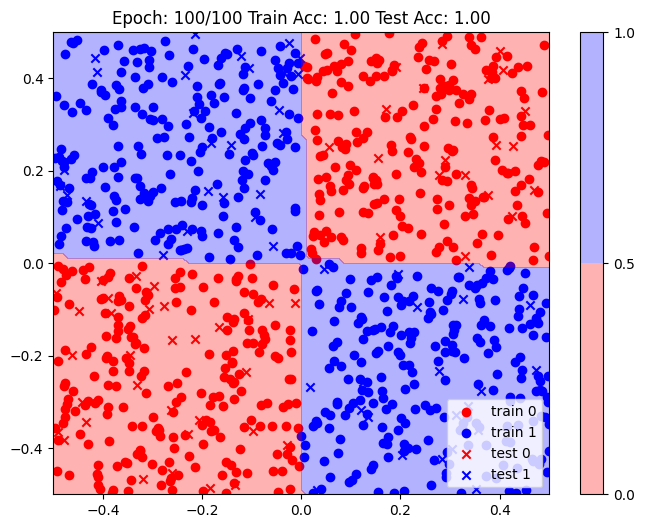

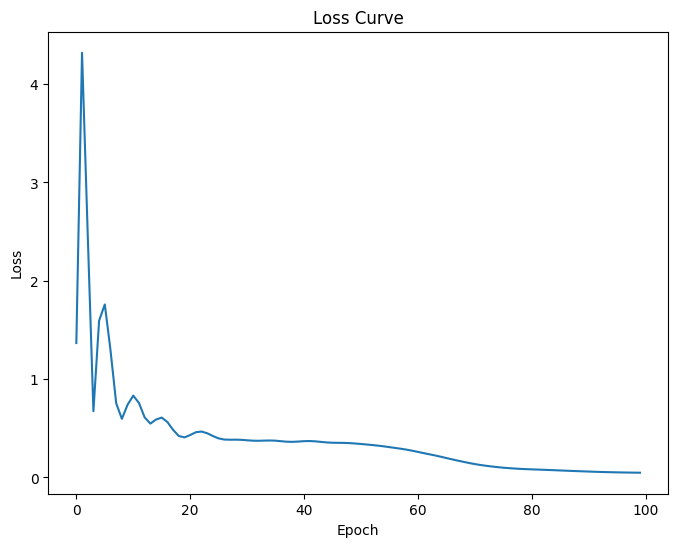

In [17]:
# Some tests for Task 4.

if is_notebook():
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=build_two_layer_mlp(2, 2, 16),
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=cross_entropy_loss,
        accuracy_fn=calculate_accuracy,
        num_epochs=100,
        print_every_epochs=10,
        evaluate_every_epochs=100,
        lr=0.1,
        temperature=0.1,
    )

Epoch: 10/100 Loss: 0.8628
Epoch: 20/100 Loss: 0.6949
Epoch: 30/100 Loss: 0.5967
Epoch: 40/100 Loss: 0.5861
Epoch: 50/100 Loss: 0.5287
Epoch: 60/100 Loss: 0.4702
Epoch: 70/100 Loss: 0.4375
Epoch: 80/100 Loss: 0.4213
Epoch: 90/100 Loss: 0.4110
Epoch: 100/100 Loss: 0.4047


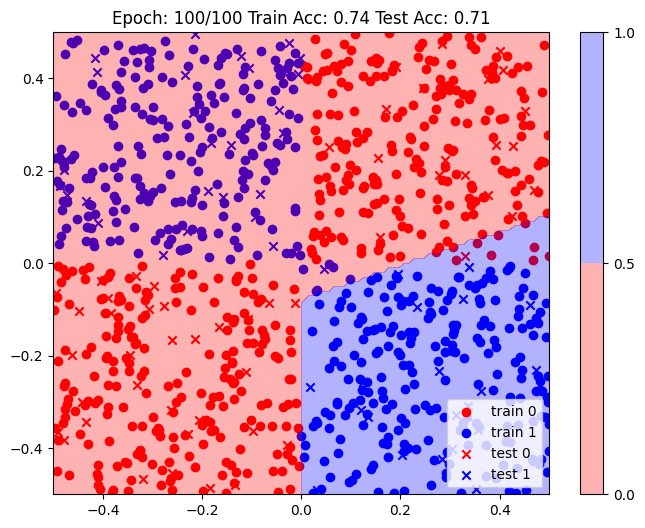

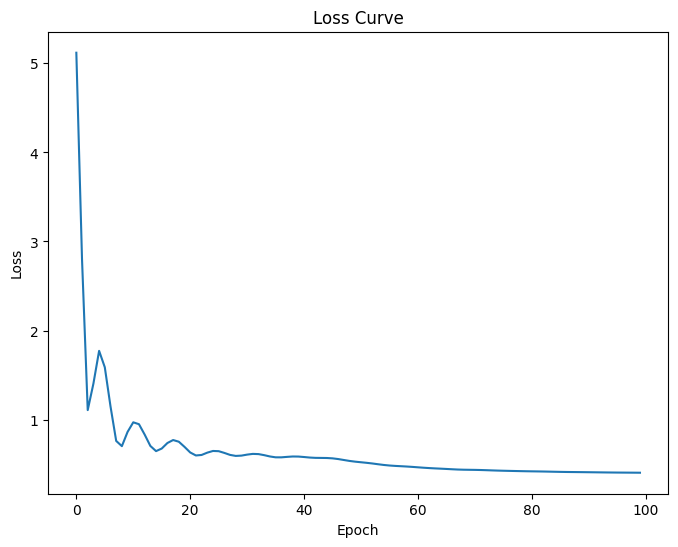

In [14]:
# Some tests for Task 4.

if is_notebook():
    # TODO: Feel free to change the hyperparameters
    train_model(
        model=build_two_layer_mlp(2, 2, 4),
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        loss_fn=cross_entropy_loss,
        accuracy_fn=calculate_accuracy,
        num_epochs=100,
        print_every_epochs=10,
        evaluate_every_epochs=100,
        lr=0.1,
        temperature=0.1,
    )

## Task 5 -- Minimum Layers for XOR 

In [15]:
# --- TASK 5 -----------------------------------------------------------------------------------------------------------
# TODO: Set this constant to the minimum number of layers required to solve the XOR problem using an MLP theoretically.
# You are welcome to borrow code from previous tasks to verify your answer.
# Be sure not to directly modify or accidentally overwrite Task 1-4 upon submission. 
# Note that we will not run your code. We'll only check the value of this constant.
MINIMUM_NUMBER_OF_LAYERS_TO_SOLVE_XOR_PROBLEM: int = ...

